In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import pickle
import time
import warnings
import platform
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

warnings.filterwarnings('ignore')

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'data'
DATA_DIR.mkdir(parents=True, exist_ok=True)

# PRICE_START : 2004-01-01 → rolling(252) 워밍업 + ret_1m 첫 행 확보
# PRICE_END   : 2026-03-31 → 2025-12 fwd_ret_1m 계산을 위해 1분기 더 수집
# PANEL_START : 2009-01-01 → 금융위기(2008) 포함을 위해 1년 앞당김
# PANEL_END   : 2025-12-31 → 실제 분석 패널 종료
PRICE_START = '2004-01-01'
PRICE_END   = '2026-03-31'
PANEL_START = '2009-01-01'
PANEL_END   = '2024-12-31'

print(f'데이터 경로: {DATA_DIR}')
print(f'가격 수집 기간: {PRICE_START} ~ {PRICE_END}')
print(f'패널 기간:     {PANEL_START} ~ {PANEL_END}')
print(f'→ TRAIN_WINDOW=36개월 시 2008-01부터 예측 가능 (금융위기 포함)')

데이터 경로: c:\workspace\camp\project\finance_project\서윤범\low_risk\data
가격 수집 기간: 2004-01-01 ~ 2026-03-31
패널 기간:     2009-01-01 ~ 2024-12-31
→ TRAIN_WINDOW=36개월 시 2008-01부터 예측 가능 (금융위기 포함)


In [2]:
with open(file = DATA_DIR / 'prices_raw.pkl', mode = 'rb') as f:
    prices_raw = pickle.load(f)

prices_raw.head()

Price      Adj Close                                          ...   Volume  \
Ticker           ABK ABMD ACAS ACE ADS AGN AKS ALTR ALXN ANR  ...      XRX   
Date                                                          ...            
2004-01-02       NaN  NaN  NaN NaN NaN NaN NaN  NaN  NaN NaN  ...  1722854   
2004-01-05       NaN  NaN  NaN NaN NaN NaN NaN  NaN  NaN NaN  ...  1562857   
2004-01-06       NaN  NaN  NaN NaN NaN NaN NaN  NaN  NaN NaN  ...  4152831   
2004-01-07       NaN  NaN  NaN NaN NaN NaN NaN  NaN  NaN NaN  ...  1605968   
2004-01-08       NaN  NaN  NaN NaN NaN NaN NaN  NaN  NaN NaN  ...  1886191   

Price                                                              
Ticker     XTO XYL XYZ YHOO      YUM      ZBH    ZBRA    ZION ZTS  
Date                                                               
2004-01-02 NaN NaN NaN  NaN  3226285   688143  339900  462900 NaN  
2004-01-05 NaN NaN NaN  NaN  2716067  1223846  640950  598400 NaN  
2004-01-06 NaN NaN NaN  NaN  4142120  1202216  311700  612200 NaN  
2004-01-07 NaN NaN NaN  NaN  3602968   866127  495150  754700 NaN  
2004-01-08 NaN NaN NaN  NaN  2597832  1114151  290850  504000 NaN  

[5 rows x 4339 columns]

In [3]:
prices_raw.columns.get_level_values(0).unique()

Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

In [ ]:
# ── 기본 설정 ─────────────────────────────────────────────────
PANEL_START  = '2010-01-01'   
PANEL_END    = '2024-12-31'
TRAIN_WINDOW = 60             # 개월 (일별 ≈ 1260거래일)

close = prices_raw['Close'].copy()
close = close[~close.index.duplicated(keep='last')]

# ^IRX 제거 (금리지수 - 주식 아님)
if '^IRX' in close.columns:
    close = close.drop(columns=['^IRX'])

log_ret = np.log(close / close.shift(1))

print(f'Close shape : {close.shape}')
print(f'기간        : {close.index[0].date()} ~ {close.index[-1].date()}')
print(f'PANEL_START : {PANEL_START}')
print(f'TRAIN_WINDOW: {TRAIN_WINDOW}개월 → 일별 약 {TRAIN_WINDOW*21}거래일')


Close shape : (5595, 834)
기간        : 2004-01-02 ~ 2026-03-30
PANEL_START : 2010-01-01
TRAIN_WINDOW: 60개월 → 일별 약 1260거래일


In [6]:
# ── Section 1. drop_tickers 확정 ──────────────────────────────
# 기준 A: 하루 사이 10배 이상 가격 변화 (데이터 오류)
# 기준 B: 60일 이상 연속 0 log_return (티커 혼재)

# --- A. 극단 수익률 ---
ratio = close / close.shift(1)
extreme_mask = (ratio > 10) | (ratio < 0.1)
bad_A = extreme_mask.sum()
bad_A = bad_A[bad_A > 0].sort_values(ascending=False)

# --- B. 연속 0 log_return ---
CONSEC_THRESH = 60  # 3개월

def max_consecutive_zero(s):
    s = s.dropna()
    if len(s) == 0:
        return 0
    max_c, cur = 0, 0
    for v in (s == 0):
        cur = cur + 1 if v else 0
        max_c = max(max_c, cur)
    return max_c

consec = {t: max_consecutive_zero(log_ret[t]) for t in log_ret.columns}
bad_B  = pd.Series(consec)
bad_B  = bad_B[bad_B >= CONSEC_THRESH].sort_values(ascending=False)

# --- 합집합 → drop_tickers ---
drop_tickers = sorted(set(bad_A.index) | set(bad_B.index))

print('=== A. 극단 수익률 (10배 이상 변화) ===')
print(bad_A.to_string())

print(f'\n=== B. 연속 0 log_return ({CONSEC_THRESH}일 이상) ===')
print(bad_B.to_string())

print(f'\n=== 최종 drop_tickers ({len(drop_tickers)}개) ===')
print(drop_tickers)


=== A. 극단 수익률 (10배 이상 변화) ===
Ticker
CBE     656
TIE     197
CFC     120
MEE      85
BMC      24
CPWR      6
PTV       5
RSH       2
POM       1

=== B. 연속 0 log_return (60일 이상) ===
CPWR    393
BMC     326
MEE     213
GLK     213
CFC     149
PTV     139
HOT     122
RSH     114
SW       69
AMCR     66

=== 최종 drop_tickers (13개) ===
['AMCR', 'BMC', 'CBE', 'CFC', 'CPWR', 'GLK', 'HOT', 'MEE', 'POM', 'PTV', 'RSH', 'SW', 'TIE']


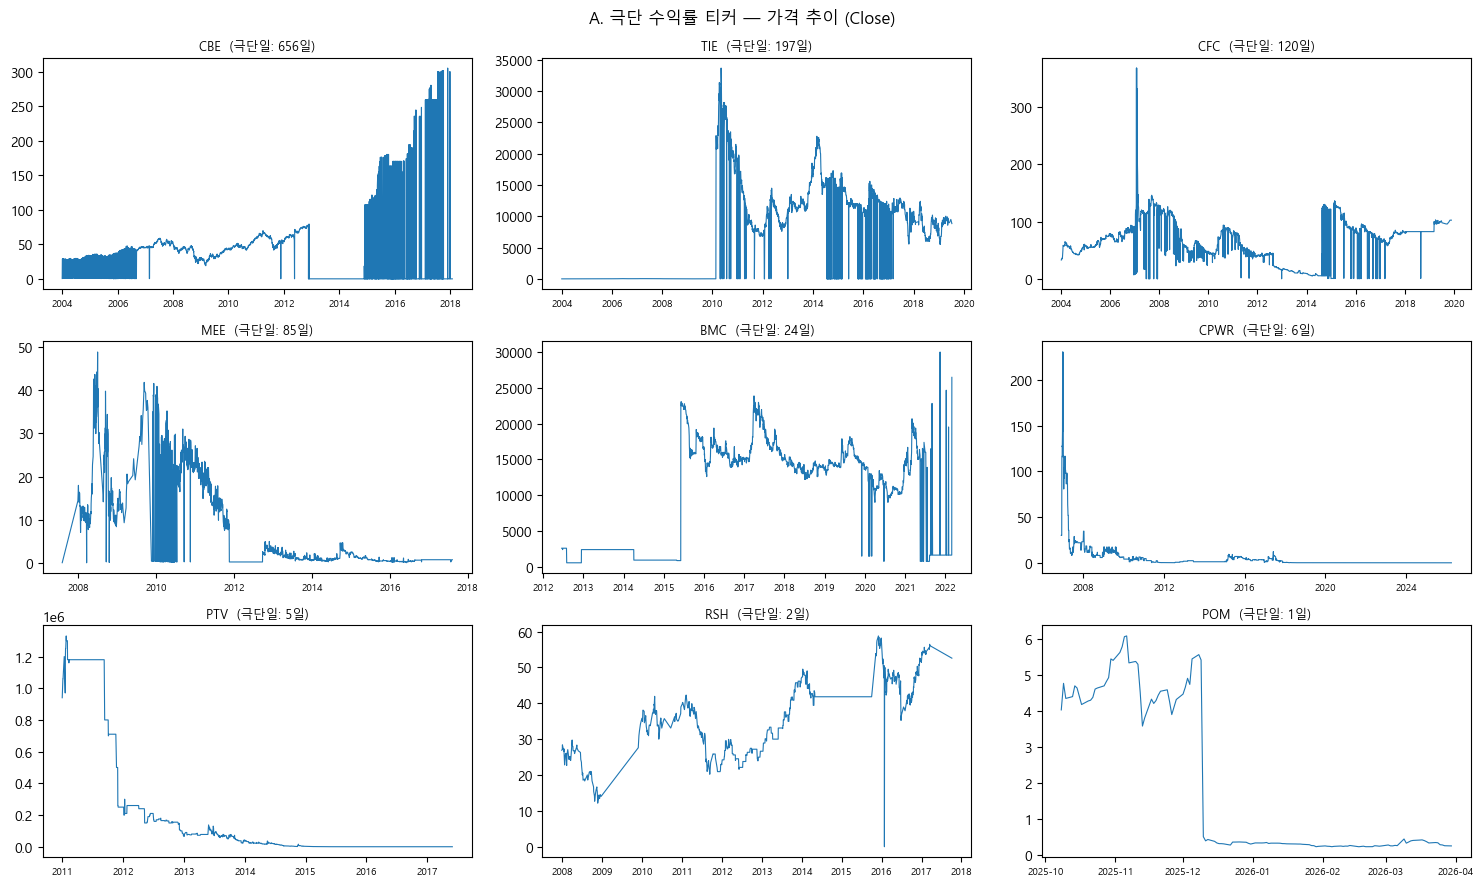

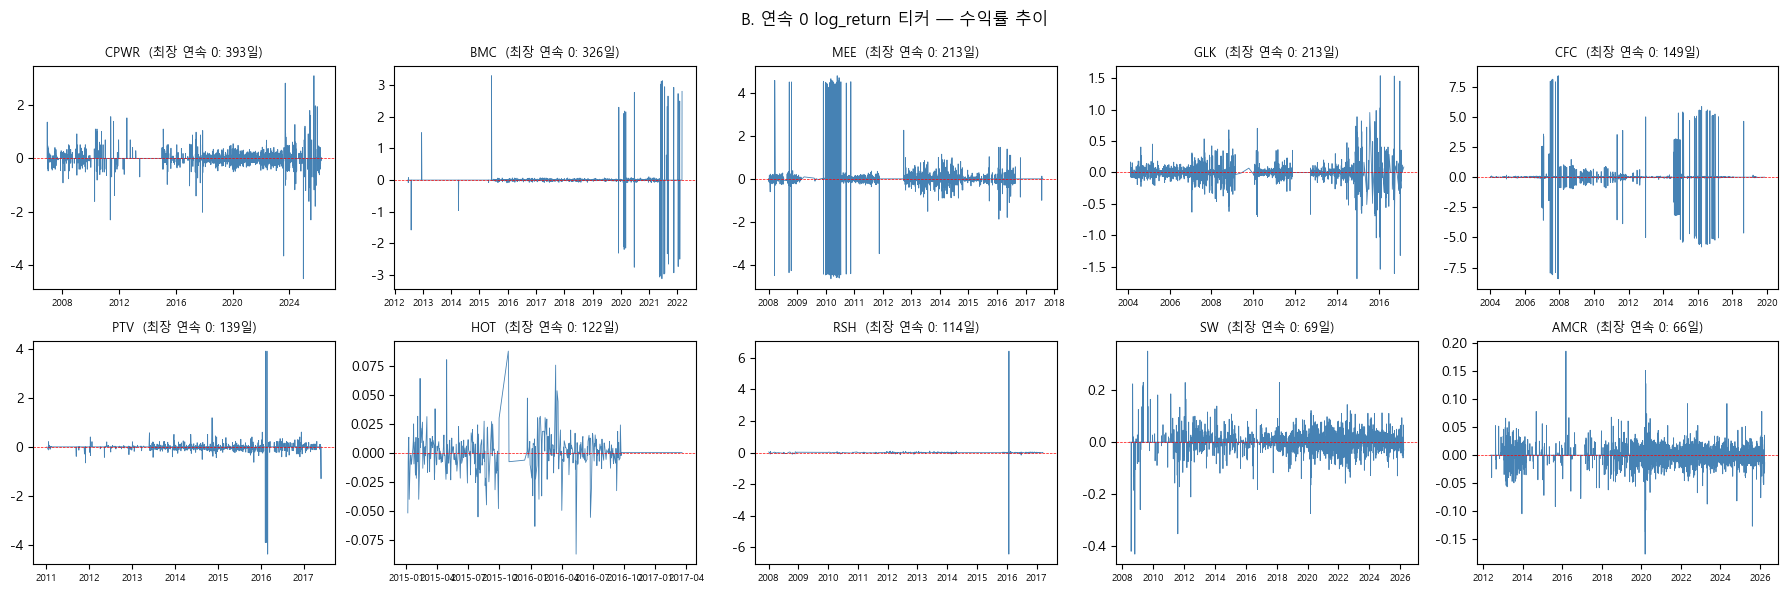

In [7]:

# ── Section 1 시각화: 문제 티커 직접 확인 ─────────────────────

# --- A. 극단 수익률: 가격 차트 ---
tickers_A = list(bad_A.index)
ncols = 3
nrows = (len(tickers_A) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3))
axes = axes.flatten()
fig.suptitle('A. 극단 수익률 티커 — 가격 추이 (Close)', fontsize=12)

for i, t in enumerate(tickers_A):
    s = close[t].dropna()
    axes[i].plot(s.index, s.values, linewidth=0.8)
    axes[i].set_title(f'{t}  (극단일: {bad_A[t]}일)', fontsize=9)
    axes[i].tick_params(axis='x', labelsize=7)

for j in range(len(tickers_A), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# --- B. 연속 0: log_return 차트 ---
tickers_B = list(bad_B.index)
ncols = 5
nrows = (len(tickers_B) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3))
axes = axes.flatten()
fig.suptitle('B. 연속 0 log_return 티커 — 수익률 추이', fontsize=12)

for i, t in enumerate(tickers_B):
    s = log_ret[t].dropna()
    axes[i].plot(s.index, s.values, linewidth=0.6, color='steelblue')
    axes[i].axhline(0, color='r', linewidth=0.5, linestyle='--')
    axes[i].set_title(f'{t}  (최장 연속 0: {bad_B[t]}일)', fontsize=9)
    axes[i].tick_params(axis='x', labelsize=7)

for j in range(len(tickers_B), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


=== thresh=0.9 기준 유효 티커 수 요약 ===
             T       N      pT
count   180.00  180.00  180.00
mean   1259.28  547.19    0.43
std       0.82   33.64    0.03
min    1258.00  483.00    0.38
25%    1259.00  517.00    0.41
50%    1259.00  552.50    0.44
75%    1260.00  577.00    0.46
max    1262.00  601.00    0.48


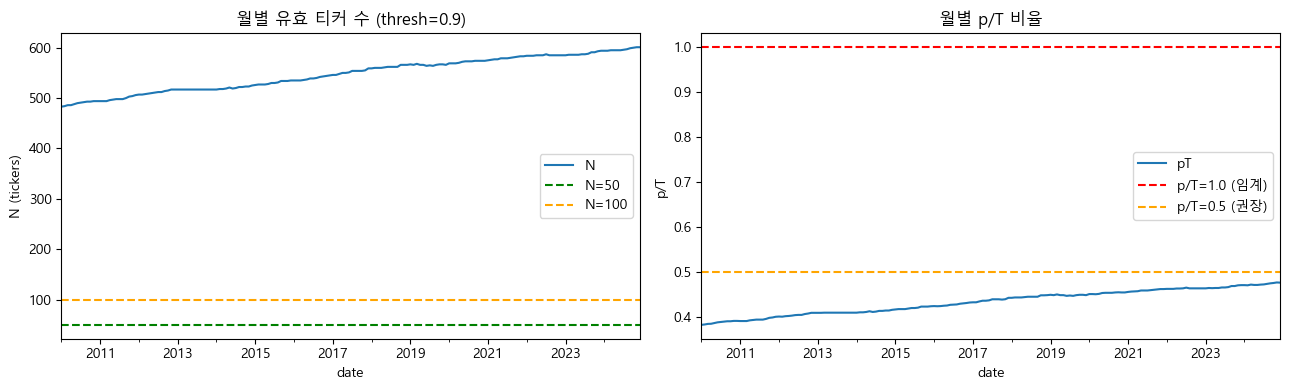

In [8]:

# ── Section 2. thresh=0.9 기준 유효 티커 수 & p/T 비율 ────────
# PANEL_START=2010 기준, 각 예측월마다 60개월 훈련 윈도우에서
# 유효 거래일 90% 이상인 티커가 몇 개인지 확인

close_clean = close.drop(columns=drop_tickers, errors='ignore')

pred_dates = pd.date_range(PANEL_START, PANEL_END, freq='ME')
THRESH_RATIO = 0.9

records = []
for pred_date in pred_dates:
    train_start = pred_date - pd.DateOffset(months=TRAIN_WINDOW)
    window = close_clean.loc[train_start:pred_date]
    T = len(window)
    thresh = int(T * THRESH_RATIO)
    valid_n = (window.notna().sum() >= thresh).sum()
    records.append({'date': pred_date, 'T': T, 'N': valid_n, 'pT': valid_n / T})

df_pt = pd.DataFrame(records).set_index('date')

print(f'=== thresh={THRESH_RATIO} 기준 유효 티커 수 요약 ===')
print(df_pt[['T', 'N', 'pT']].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df_pt['N'].plot(ax=axes[0], title='월별 유효 티커 수 (thresh=0.9)')
axes[0].set_ylabel('N (tickers)')
axes[0].axhline(50,  color='g', linestyle='--', label='N=50')
axes[0].axhline(100, color='orange', linestyle='--', label='N=100')
axes[0].legend()

df_pt['pT'].plot(ax=axes[1], title='월별 p/T 비율')
axes[1].axhline(1.0, color='r',      linestyle='--', label='p/T=1.0 (임계)')
axes[1].axhline(0.5, color='orange', linestyle='--', label='p/T=0.5 (권장)')
axes[1].set_ylabel('p/T')
axes[1].legend()

plt.tight_layout()
plt.show()


In [14]:

# ── Section 3. shares_map 없는 51개 영향도 ────────────────────
# log(Close) 대체 사용 종목이 실제 패널(2010~)에 얼마나 등장하는지

with open(DATA_DIR / 'shares_outstanding.pkl', 'rb') as f:
    shares_map = pickle.load(f)
with open(DATA_DIR / 'sp500_membership.pkl', 'rb') as f:
    sp500_membership = pickle.load(f)

universe = pd.read_csv(DATA_DIR / 'universe.csv')
tickers_all = universe['ticker'].tolist()

no_shares = [t for t in tickers_all if t not in shares_map and t not in drop_tickers]

# 패널 기간(2010~2024) S&P500 멤버십에 등장한 월 수 계산
membership_dates = sorted(sp500_membership.keys())
panel_dates = [d for d in membership_dates
               if pd.Timestamp(PANEL_START) <= d <= pd.Timestamp(PANEL_END)]

appearance = {t: 0 for t in no_shares}
for d in panel_dates:
    members = sp500_membership[d]
    for t in no_shares:
        if t in members:
            appearance[t] += 1

app_series = pd.Series(appearance).sort_values(ascending=False)
appeared   = app_series[app_series > 0]

print(f'=== shares_map 없는 종목 (drop 제외) ===')
print(f'전체: {len(no_shares)}개  |  2010~ 패널 등장: {len(appeared)}개  |  미등장: {len(no_shares)-len(appeared)}개')
print()
print('[패널 등장 종목 — 등장 월수]')
print(appeared.to_string())

total_slots = len(panel_dates) * close_clean.shape[1]
impact_slots = appeared.sum()
print(f'\n전체 패널 슬롯 대비 영향 비율: {impact_slots}/{total_slots} = {impact_slots/total_slots:.2%}')


=== shares_map 없는 종목 (drop 제외) ===
전체: 43개  |  2010~ 패널 등장: 29개  |  미등장: 14개

[패널 등장 종목 — 등장 월수]
FDO     66
TEG     66
LO      65
CFN     62
SWY     60
MOLX    47
JDSU    47
COV     47
NYX     46
HNZ     41
CVH     40
PCS     39
KFT     33
KRFT    33
GR      30
PETM    29
MHS     27
WFR     23
TLAB    23
CEPH    21
ANR     16
GENZ    15
NOVL    15
MFE     13
AYE     13
EK      11
XTO      5
BJS      3
RX       1

전체 패널 슬롯 대비 영향 비율: 937/147780 = 0.63%
